### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1533]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [1534]:
data = pd.read_csv('data/coupons.csv')

In [1535]:
data = data.rename(columns={'passanger': 'passenger'})


# For my reference
g = """
--- User attributes ---
gender: male or female
maritalStatus: marital status
has_children: whether the customer has children
education: education level
age: customer's age
occupation: customer's occupation
income: customer's income
Bar: How often the customer goes to a bar per month
CoffeeHouse: How often the customer goes to a coffee house
CarryAway: How often the customer goes to a carry out place
RestaurantLessThan20: How often the customer goes to a restaurant under $20
Restaurant20To50: How often the customer goes to a restaurant between $20 and $50

--- Context ---
destination: where the customer is going
passenger: who the passenger is
weather: what the weather is like
temperature: temperature in Fahrenheit
time: time of day when the coupon is issued
direction_same: 1 if the customer is going in the same direction as the coupon, 0 if opposite
direction_opp: 1 if the customer is going in the opposite direction as the coupon, 0 if same

--- Coupon details ---
coupon: type of coupon. Bar, CoffeeHouse, CarryOut, RestaurantLessThan20, Restaurant20To50
expiration: how long until the coupon expires
toCoupon_GEQ5min: 1 if the coupon venue is more than 5 minutes away from the driver's current location.
toCoupon_GEQ15min: 1 if the coupon venue is more than 15 minutes away from the driver's current location.
toCoupon_GEQ25min: 1 if the coupon venue is more than 25 minutes away from the driver's current location.

--- Result ---
Y: Whether the customer accepted the coupon

"""

2. Investigate the dataset for missing or problematic data.

In [1536]:
# Understand the data
print(data.isna().sum())

# Create a new column to store the maximum value. Value to be stored is either max of (5, 15 or 25)
data['toCoupon'] = data.apply(lambda x: max(x['toCoupon_GEQ5min'] * 5,  x['toCoupon_GEQ15min'] * 15, x['toCoupon_GEQ25min'] * 25), axis=1)


destination                 0
passenger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64


3. Decide what to do about your missing data -- drop, replace, other...

In [1537]:
# Remove the car column as it has 12576 NaN values out of 12684.
data = data.drop(columns=['car'])
l1 = len(data)
# Drop the NaN values in the remaining columns. This has negligible impact.
data = data.dropna(subset=['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50'])
l2 = len(data)

# Drop the remaining 605 rows. We are removing about 4.77% of the data, so this has negligible impact.
print(f"Dropped {l1 - l2} rows containing NaN values. Now we have {l2} rows.")


Dropped 605 rows containing NaN values. Now we have 12079 rows.


4. What proportion of the total observations chose to accept the coupon?



Proportion of customers who accepted the coupon: 56.93%


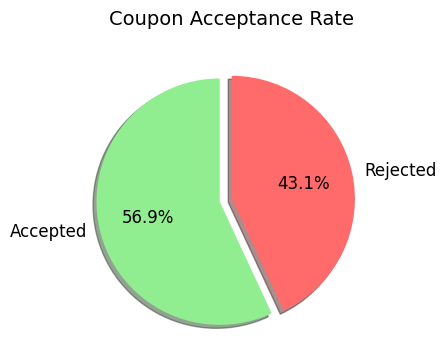

In [1538]:
# Create some helper functions that will be used in all cells.

# Proportion of customers who accepted the coupon in the dataset passed as arg.
def acceptance_rate(df):
    if len(df) == 0:
        return 0.0
    return df['Y'].mean() * 100

# Format percentage as string.
def format_perc(val):
    return f"{val:.2f}%"

acceptance_pct = acceptance_rate(data)
print(f"Proportion of customers who accepted the coupon: {format_perc(acceptance_pct)}")

# Create pie chart
rejection_pct = 100 - acceptance_pct
plt.figure(figsize=(4, 4))
sizes = [acceptance_pct, rejection_pct]
labels = ['Accepted', 'Rejected']
colors = ['#90EE90', '#FF6B6B']  # Green for accepted, red for rejected
explode = (0.10, 0)

plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=explode,
        shadow=True, textprops={'fontsize': 12})
plt.title('Coupon Acceptance Rate', fontsize=14, pad=15)
plt.savefig('images/coupon_acceptance_rate.png')
plt.show()


5. Use a bar plot to visualize the `coupon` column.

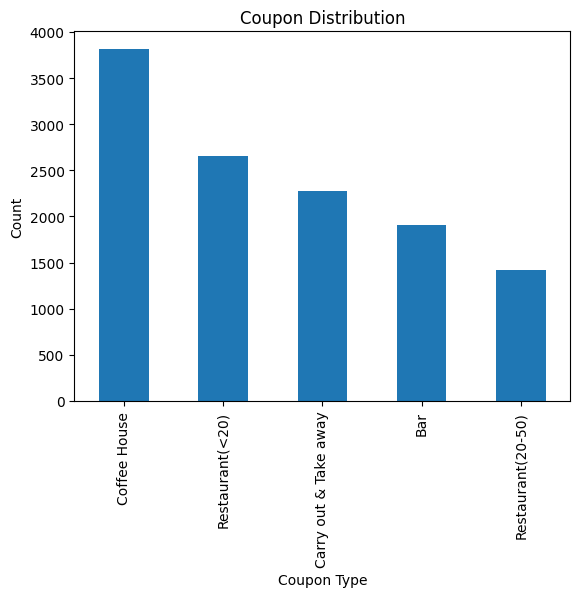

In [1539]:
data['coupon'].value_counts().plot(kind='bar')
plt.title('Coupon Distribution')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.savefig('images/coupon_distribution.png')
plt.show()


6. Use a histogram to visualize the temperature column.

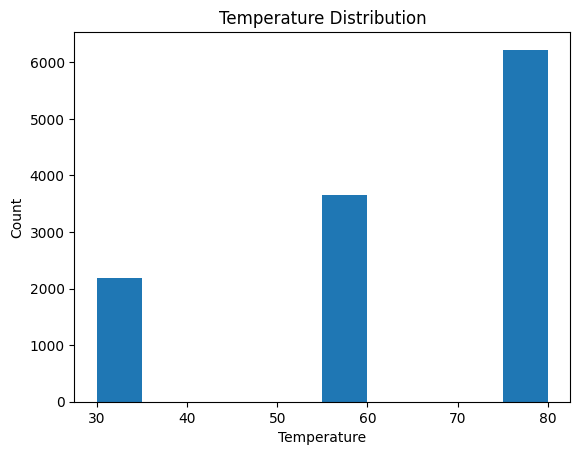

In [1540]:
data['temperature'].plot(kind="hist")
plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.savefig('images/temperature_distribution.png')
plt.show()


**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [1541]:
df_bar = data.query("coupon == 'Bar'")
print(f"Number of bar coupons in the dataset: {len(df_bar)}")

Number of bar coupons in the dataset: 1913


2. What proportion of bar coupons were accepted?


Proportion of customers who accepted the Bar coupon: 41.19%


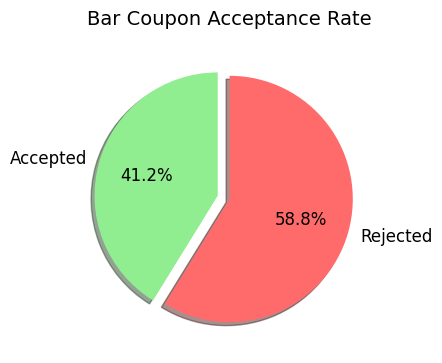

In [1542]:
acceptance_bar_coupon = acceptance_rate(df_bar)
print(f"Proportion of customers who accepted the Bar coupon: {format_perc(acceptance_bar_coupon)}")

# Create pie chart
rejection_bar_pct = 100 - acceptance_bar_coupon
plt.figure(figsize=(4, 4))
sizes = [acceptance_bar_coupon, rejection_bar_pct]
labels = ['Accepted', 'Rejected']
colors = ['#90EE90', '#FF6B6B']  # Green for accepted, red for rejected
explode = (0.10, 0)

plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=explode,
        shadow=True, textprops={'fontsize': 12})
plt.title('Bar Coupon Acceptance Rate', fontsize=14, pad=15)
plt.savefig('images/bar_coupon_acceptance.png')
plt.show()


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


Acceptance rate: bar visits 3 or fewer times/month: 37.27%
Acceptance rate: bar visits more than 3 times/month: 76.17%
Frequent bar visitors are more likely to accept the coupon.


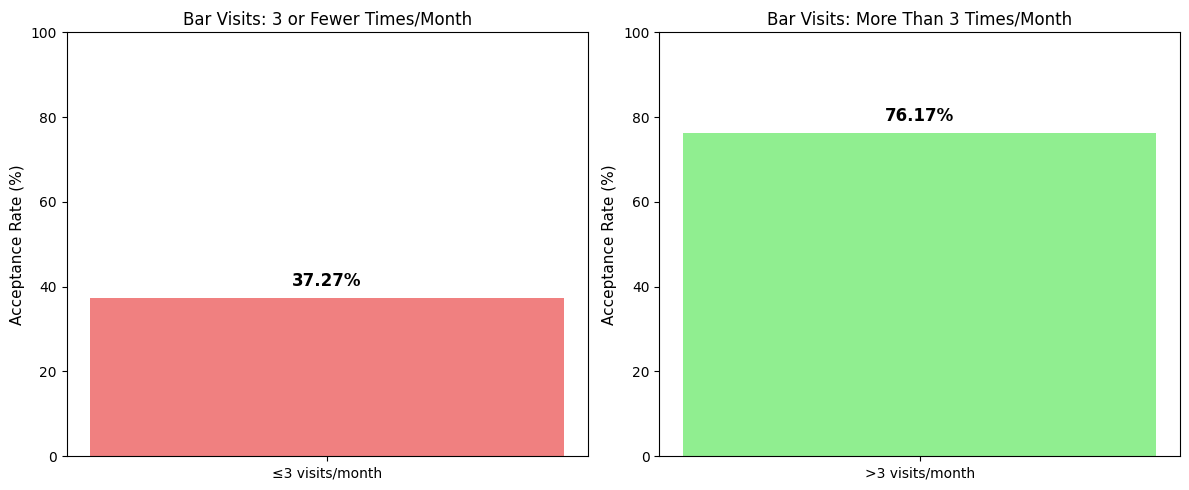

In [1543]:
list_3_or_few = ['never', 'less1', '1~3']

acceptance_bar_3_or_fewer = acceptance_rate(df_bar.query('Bar in @list_3_or_few'))
print(f"Acceptance rate: bar visits 3 or fewer times/month: {format_perc(acceptance_bar_3_or_fewer)}")

acceptance_bar_more_than_3 = acceptance_rate(df_bar.query('Bar not in @list_3_or_few'))
print(f"Acceptance rate: bar visits more than 3 times/month: {format_perc(acceptance_bar_more_than_3)}")

print(f"Frequent bar visitors are more likely to accept the coupon.")

# Comparison of bar visit frequency groups
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: ≤3 visits/month
ax1.bar(['≤3 visits/month'], [acceptance_bar_3_or_fewer], color='lightcoral', width=0.5)
ax1.set_ylabel('Acceptance Rate (%)', fontsize=11)
ax1.set_title('Bar Visits: 3 or Fewer Times/Month', fontsize=12)
ax1.set_ylim(0, 100)
ax1.text(0, acceptance_bar_3_or_fewer + 3, f'{acceptance_bar_3_or_fewer:.2f}%',
         ha='center', fontsize=12, fontweight='bold')

# Subplot 2: >3 visits/month
ax2.bar(['>3 visits/month'], [acceptance_bar_more_than_3], color='lightgreen', width=0.5)
ax2.set_ylabel('Acceptance Rate (%)', fontsize=11)
ax2.set_title('Bar Visits: More Than 3 Times/Month', fontsize=12)
ax2.set_ylim(0, 100)
ax2.text(0, acceptance_bar_more_than_3 + 3, f'{acceptance_bar_more_than_3:.2f}%',
         ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('images/bar_visit_frequency_comparison.png')
plt.show()


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


Acceptance rate: bar visitors >1/month, age >25: 68.98%
Acceptance rate: bar visitors ≤1/month OR age ≤25:  33.77%
Those who visit bar more than once a month and are over 25 have a higher acceptance rate. 
This is likely due to them being employed and having more disposable income.


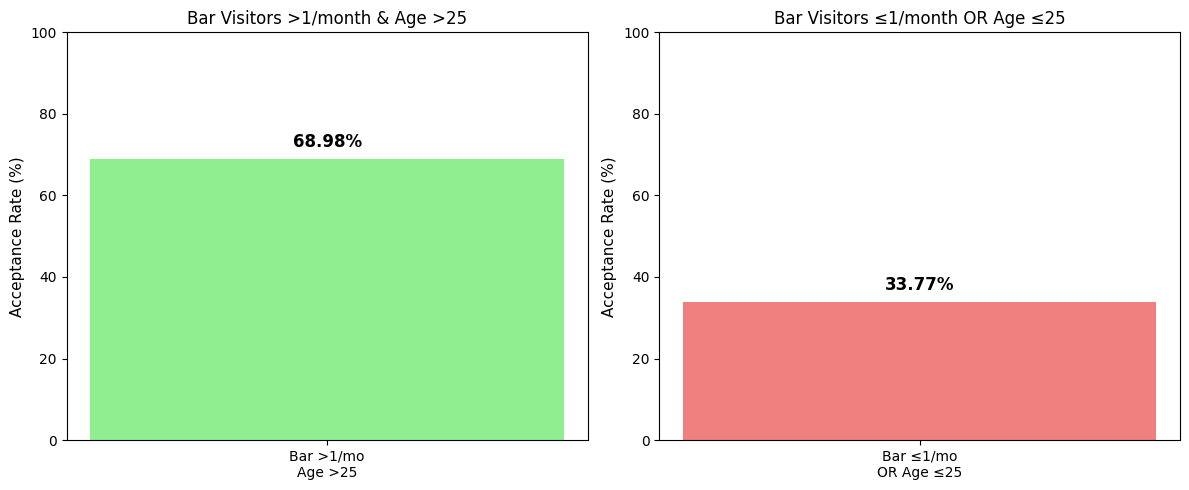

In [1544]:
age_less_25 = ['21', 'below21']
bar_less_than_1 = ['never', 'less1']

drivers_25plus_bar_once_atleast = df_bar.query("age not in @age_less_25 and Bar not in @bar_less_than_1")
drivers_25plus_bar_once_atleast_prop = acceptance_rate(drivers_25plus_bar_once_atleast)
print(f"Acceptance rate: bar visitors >1/month, age >25: {format_perc(drivers_25plus_bar_once_atleast_prop)}")


not_drivers_25plus_bar_once_atleast = df_bar[~df_bar.index.isin(drivers_25plus_bar_once_atleast.index)]
not_drivers_25plus_bar_once_atleast_prop = acceptance_rate(not_drivers_25plus_bar_once_atleast)
print(f"Acceptance rate: bar visitors ≤1/month OR age ≤25:  {format_perc(not_drivers_25plus_bar_once_atleast_prop)}")

print("Those who visit bar more than once a month and are over 25 have a higher acceptance rate. \nThis is likely due to them being employed and having more disposable income.")

# Comparison of age and bar visit frequency groups
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Bar visitors >1/month, age >25
ax1.bar(['Bar >1/mo\nAge >25'], [drivers_25plus_bar_once_atleast_prop], color='lightgreen', width=0.5)
ax1.set_ylabel('Acceptance Rate (%)', fontsize=11)
ax1.set_title('Bar Visitors >1/month & Age >25', fontsize=12)
ax1.set_ylim(0, 100)
ax1.text(0, drivers_25plus_bar_once_atleast_prop + 3, f'{drivers_25plus_bar_once_atleast_prop:.2f}%',
         ha='center', fontsize=12, fontweight='bold')

# Subplot 2: Bar visitors ≤1/month OR age ≤25
ax2.bar(['Bar ≤1/mo\nOR Age ≤25'], [not_drivers_25plus_bar_once_atleast_prop], color='lightcoral', width=0.5)
ax2.set_ylabel('Acceptance Rate (%)', fontsize=11)
ax2.set_title('Bar Visitors ≤1/month OR Age ≤25', fontsize=12)
ax2.set_ylim(0, 100)
ax2.text(0, not_drivers_25plus_bar_once_atleast_prop + 3, f'{not_drivers_25plus_bar_once_atleast_prop:.2f}%',
         ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('images/bar_age_frequency_comparison.png')
plt.show()


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


Acceptance rate: bar visitors >1/month, no kid passengers, non-farming occupations: 70.94%
Acceptance rate: bar visitors ≤1/month OR kid passengers OR farming occupations: 29.79%


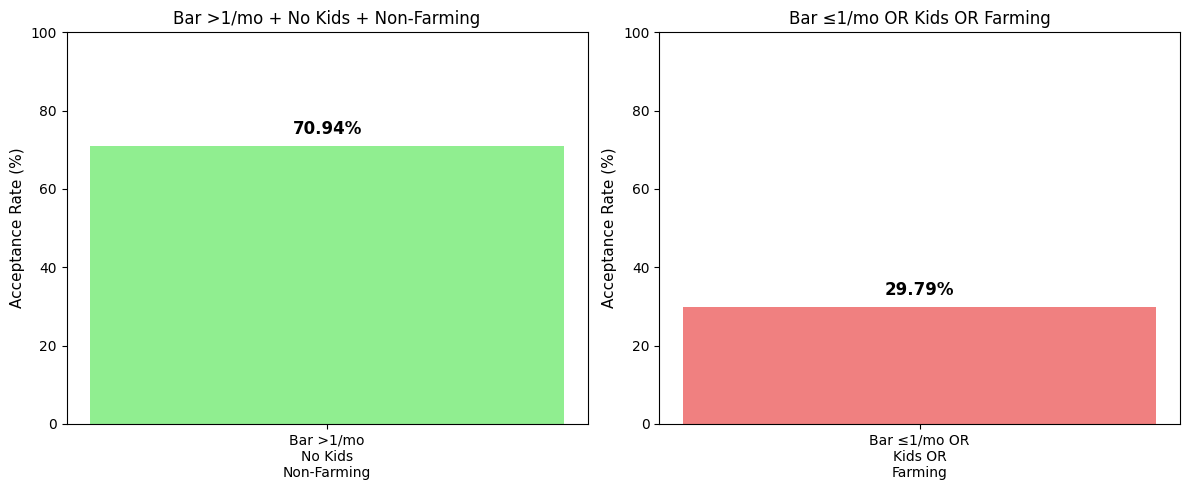

In [1545]:

occupations = ['Farming Fishing & Forestry']

acceptance_bar_freq_no_kids_non_farm = df_bar.query('Bar not in @bar_less_than_1 and occupation not in @occupations and passenger != "Kid(s)"')
acceptance_bar_freq_no_kids_non_farm_prop = acceptance_rate(acceptance_bar_freq_no_kids_non_farm)
print(f"Acceptance rate: bar visitors >1/month, no kid passengers, non-farming occupations: {format_perc(acceptance_bar_freq_no_kids_non_farm_prop)}")

not_acceptance_bar_freq_no_kids_non_farm = df_bar[~df_bar.index.isin(acceptance_bar_freq_no_kids_non_farm.index)]
not_acceptance_bar_freq_no_kids_non_farm_prop = acceptance_rate(not_acceptance_bar_freq_no_kids_non_farm)
print(f"Acceptance rate: bar visitors ≤1/month OR kid passengers OR farming occupations: {format_perc(not_acceptance_bar_freq_no_kids_non_farm_prop)}")

# Simple comparison of bar visitors with no kids and non-farming occupations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Bar >1/mo, no kids, non-farming
ax1.bar(['Bar >1/mo\nNo Kids\nNon-Farming'], [acceptance_bar_freq_no_kids_non_farm_prop], color='lightgreen', width=0.5)
ax1.set_ylabel('Acceptance Rate (%)', fontsize=11)
ax1.set_title('Bar >1/mo + No Kids + Non-Farming', fontsize=12)
ax1.set_ylim(0, 100)
ax1.text(0, acceptance_bar_freq_no_kids_non_farm_prop + 3, f'{acceptance_bar_freq_no_kids_non_farm_prop:.2f}%',
         ha='center', fontsize=12, fontweight='bold')

# Subplot 2: All others
ax2.bar(['Bar ≤1/mo OR\nKids OR\nFarming'], [not_acceptance_bar_freq_no_kids_non_farm_prop], color='lightcoral', width=0.5)
ax2.set_ylabel('Acceptance Rate (%)', fontsize=11)
ax2.set_title('Bar ≤1/mo OR Kids OR Farming', fontsize=12)
ax2.set_ylim(0, 100)
ax2.text(0, not_acceptance_bar_freq_no_kids_non_farm_prop + 3, f'{not_acceptance_bar_freq_no_kids_non_farm_prop:.2f}%',
         ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('images/bar_kids_occupation_comparison.png')
plt.show()


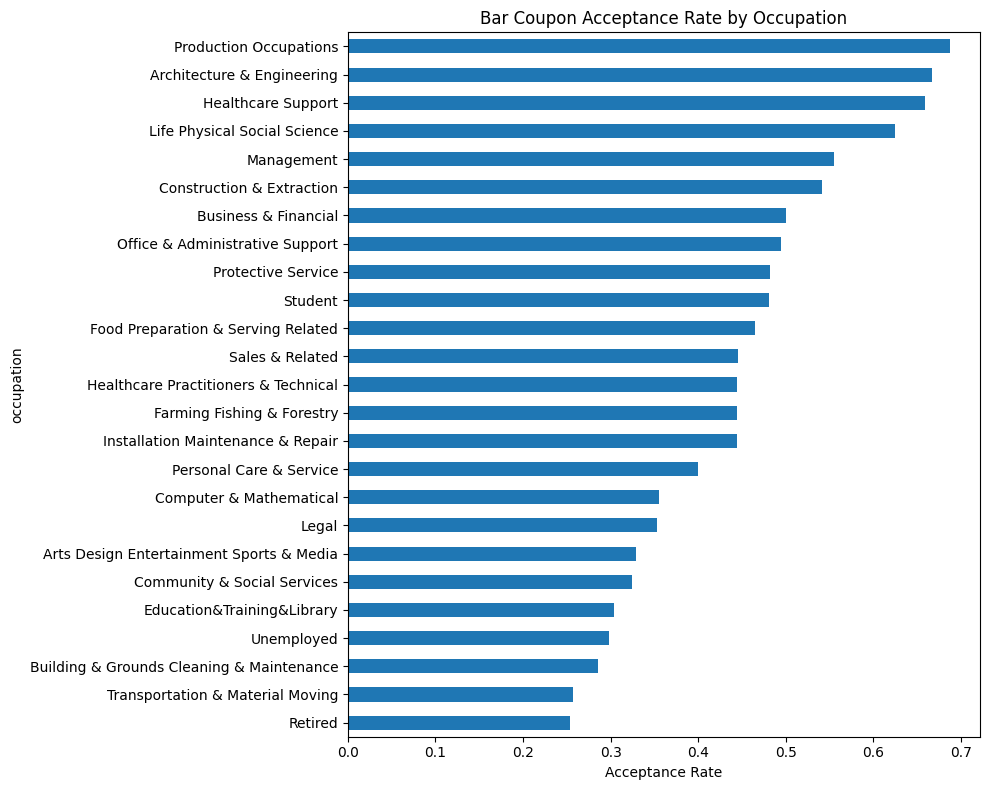

Drivers with low income such as Retired or in "Transportation & Material Moving" are less likely to accept the coupons compared to high earners in Production, Engineering and Healthcare sectors.


In [1546]:
df_bar.groupby('occupation')['Y'].mean().sort_values().plot.barh(figsize=(10, 8))
plt.xlabel('Acceptance Rate')
plt.title('Bar Coupon Acceptance Rate by Occupation')
plt.tight_layout()
plt.show()

print('Drivers with low income such as Retired or in "Transportation & Material Moving" are less likely to accept the coupons compared to high earners in Production, Engineering and Healthcare sectors.')


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



Acceptance rate: bar visitors >1/month, no kid passengers, not widowed: 70.94%
Acceptance rate: bar visitors >1/month, age <30: 71.95%
Acceptance rate: cheap restaurant visitors >4/month, income <$50K: 45.65%


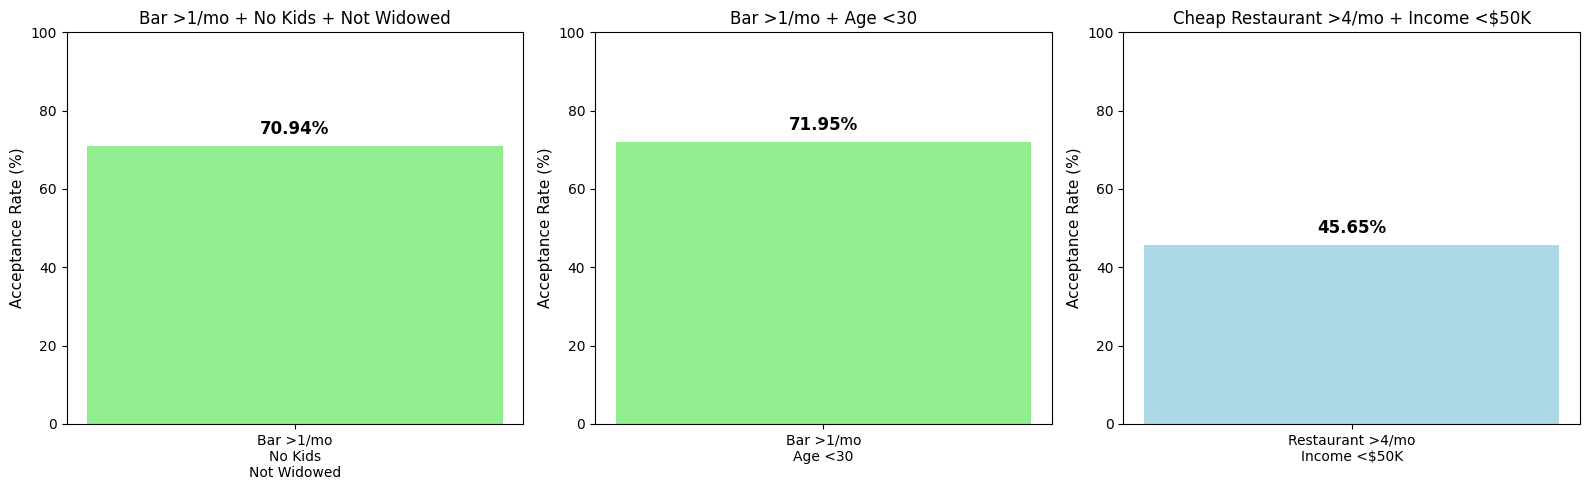

In [1547]:
acceptance_bar_freq_no_kids_non_farm = acceptance_rate(df_bar.query(
    "Bar not in @bar_less_than_1 and "
    "maritalStatus != 'Widowed' and "
    "passenger != 'Kid(s)'"
))
print(f"Acceptance rate: bar visitors >1/month, no kid passengers, not widowed: {format_perc(acceptance_bar_freq_no_kids_non_farm)}")

age_less_30 = ['21', 'below21', '26']
acceptance_bar_freq_under_30 = acceptance_rate(df_bar.query(
    "Bar not in @bar_less_than_1 and "
    "age in @age_less_30"
))
print(f"Acceptance rate: bar visitors >1/month, age <30: {format_perc(acceptance_bar_freq_under_30)}")

rest_visit_4plus = ['4~8', 'gt8']
income_less_50k = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

acceptance_budget_dining_under_50k = acceptance_rate(df_bar.query(
    "RestaurantLessThan20 in @rest_visit_4plus and "
    "income in @income_less_50k"
))
print(f"Acceptance rate: cheap restaurant visitors >4/month, income <$50K: {format_perc(acceptance_budget_dining_under_50k)}")

# Comparison of three different driver segments
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Subplot 1: Bar >1/mo, no kids, not widowed
ax1.bar(['Bar >1/mo\nNo Kids\nNot Widowed'], [acceptance_bar_freq_no_kids_non_farm], color='lightgreen', width=0.5)
ax1.set_ylabel('Acceptance Rate (%)', fontsize=11)
ax1.set_title('Bar >1/mo + No Kids + Not Widowed', fontsize=12)
ax1.set_ylim(0, 100)
ax1.text(0, acceptance_bar_freq_no_kids_non_farm + 3, f'{acceptance_bar_freq_no_kids_non_farm:.2f}%',
         ha='center', fontsize=12, fontweight='bold')

# Subplot 2: Bar >1/mo, age <30
ax2.bar(['Bar >1/mo\nAge <30'], [acceptance_bar_freq_under_30], color='lightgreen', width=0.5)
ax2.set_ylabel('Acceptance Rate (%)', fontsize=11)
ax2.set_title('Bar >1/mo + Age <30', fontsize=12)
ax2.set_ylim(0, 100)
ax2.text(0, acceptance_bar_freq_under_30 + 3, f'{acceptance_bar_freq_under_30:.2f}%',
         ha='center', fontsize=12, fontweight='bold')

# Subplot 3: Cheap restaurant >4/mo, income <$50K
ax3.bar(['Restaurant >4/mo\nIncome <$50K'], [acceptance_budget_dining_under_50k], color='lightblue', width=0.5)
ax3.set_ylabel('Acceptance Rate (%)', fontsize=11)
ax3.set_title('Cheap Restaurant >4/mo + Income <$50K', fontsize=12)
ax3.set_ylim(0, 100)
ax3.text(0, acceptance_budget_dining_under_50k + 3, f'{acceptance_budget_dining_under_50k:.2f}%',
         ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('images/bar_three_segments_comparison.png')
plt.show()


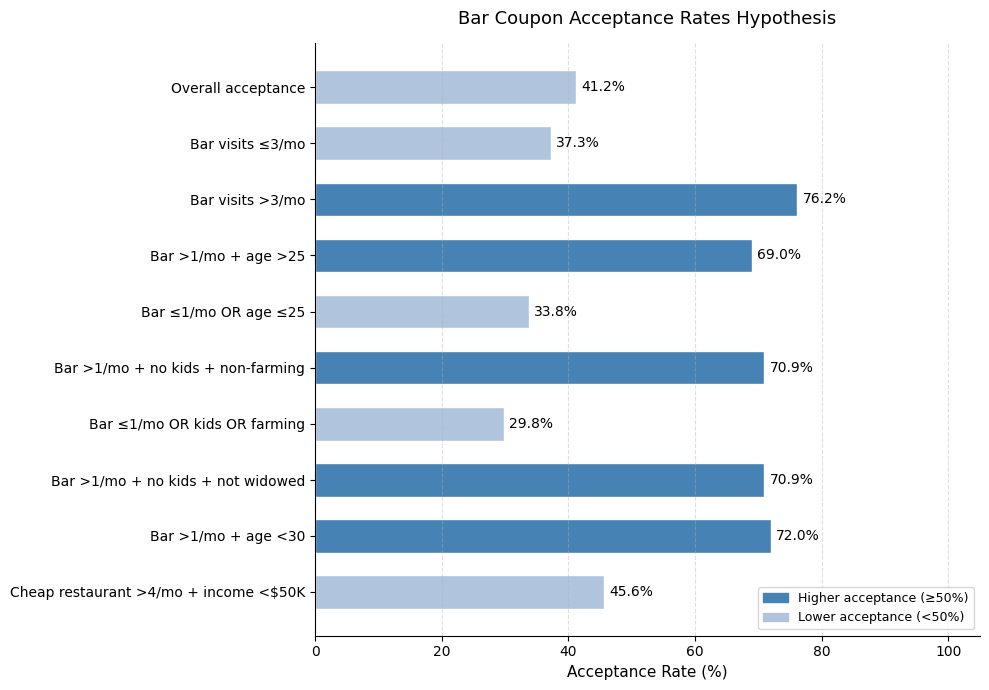

In [1548]:
# Summary of Bar Coupon Acceptance Rates Hypothesis
segments = [
    'Overall acceptance',
    'Bar visits ≤3/mo',
    'Bar visits >3/mo',
    'Bar >1/mo + age >25',
    'Bar ≤1/mo OR age ≤25',
    'Bar >1/mo + no kids + non-farming',
    'Bar ≤1/mo OR kids OR farming',
    'Bar >1/mo + no kids + not widowed',
    'Bar >1/mo + age <30',
    'Cheap restaurant >4/mo + income <$50K'
]

rates = [
    acceptance_bar_coupon,
    acceptance_bar_3_or_fewer,
    acceptance_bar_more_than_3,
    drivers_25plus_bar_once_atleast_prop,
    not_drivers_25plus_bar_once_atleast_prop,
    acceptance_bar_freq_no_kids_non_farm_prop,
    not_acceptance_bar_freq_no_kids_non_farm_prop,
    acceptance_bar_freq_no_kids_non_farm,
    acceptance_bar_freq_under_30,
    acceptance_budget_dining_under_50k
]

# Color based on threshold
colors = ['steelblue' if r >= 50 else 'lightsteelblue' for r in rates]

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(segments, rates, color=colors, edgecolor='white', height=0.6)

# Add value labels
for bar, val in zip(bars, rates):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlim(0, 105)
ax.set_xlabel('Acceptance Rate (%)', fontsize=11)
ax.set_title('Bar Coupon Acceptance Rates Hypothesis', fontsize=13, pad=14)
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

# Legend
ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Higher acceptance (≥50%)'),
    mpatches.Patch(color='lightsteelblue', label='Lower acceptance (<50%)')
], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('images/bar_coupon_acceptance_rates_hypothesis.png')
plt.show()


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

##### Key Insight

The single strongest predictor is bar visit frequency.  
Drivers who go to bars more than 3 times a month accept at 76%, roughly double the rate of those who go 3 or fewer times (37%). Frequent bar-goers are already in the habit, so a coupon feels like a natural fit rather than a behavioral nudge toward something unfamiliar.

##### Accepting Driver Profile

Across multiple segmentations, a consistent profile emerges.

Drivers most likely to accept the coupon tend to be:
- Regular bar-goers (more than once a month)
- Under 30 or at least over 25
- Traveling without children in the car
- Not working in farming or related occupations

Different variable combinations converge on roughly 70–72% acceptance, suggesting they represent the same underlying driver profile.

##### Rejecting Driver Profile

Drivers least likely to accept tend to be:
- Rare or non-bar-goers
- Traveling with children (family context where a bar coupon is less relevant)
- Working in *farming-related occupations

These groups typically show 29–37% acceptance.

##### Occupational preferences

Drivers with low income such as Retired or in "Transportation & Material Moving" are less likely to accept the coupons compared to high earners in Production, Engineering and Healthcare sectors.


##### Borderline Segment

The cheap restaurant + low income group (45.65%) sits in the middle.  
This suggests budget-conscious drivers show some openness, but without an existing bar-going habit, the coupon is not compelling enough to significantly increase acceptance.

##### Conclusion

Drivers most likely to accept a bar coupon are:
- Habitual bar-goers
- Younger adults
- Drivers without children in the car at that moment

Situational context (kids in the car) and occupation reduce acceptance even among moderate drinkers, indicating that moment-of-delivery context matters as much as lifestyle habits.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

# Correlation of Coffee coupon acceptance and temperature

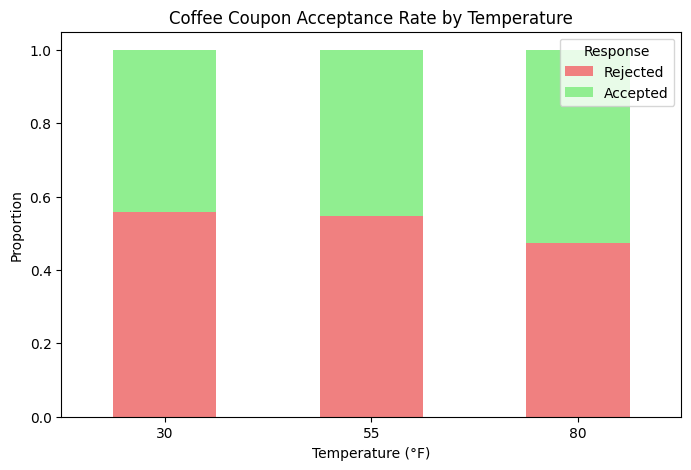

Coffee coupon is accepted more when temperature is high.
This is possible due to the fact that the weather is good.


In [1549]:
df_coffee = data.query("coupon == 'Coffee House'")
len(df_coffee)

# Calculate acceptance rates by temperature using stacked bar graph
temp_acceptance = df_coffee.groupby('temperature')['Y'].value_counts(normalize=True).unstack()

temp_acceptance.plot(kind='bar', stacked=True, figsize=(8, 5),
                     color=['lightcoral', 'lightgreen'])
plt.title('Coffee Coupon Acceptance Rate by Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Proportion')
plt.legend(['Rejected', 'Accepted'], title='Response')
plt.xticks(rotation=0)
plt.savefig('images/coffee_coupon_acceptance_by_temperature.png')
plt.show()

print("Coffee coupon is accepted more when temperature is high.\nThis is possible due to the fact that the weather is good.")


# Correlation of Coffee coupon acceptance and weather

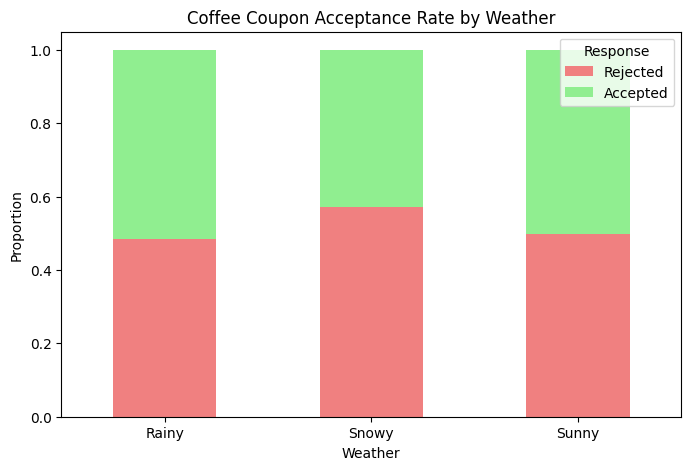

Coffee coupon is accepted more when temperature is sunny & rainy


In [1550]:
# Calculate acceptance rates by weather using stacked bar graph
temp_acceptance = df_coffee.groupby('weather')['Y'].value_counts(normalize=True).unstack()

temp_acceptance.plot(kind='bar', stacked=True, figsize=(8, 5),
                     color=['lightcoral', 'lightgreen'])
plt.title('Coffee Coupon Acceptance Rate by Weather')
plt.xlabel('Weather')
plt.ylabel('Proportion')
plt.legend(['Rejected', 'Accepted'], title='Response')
plt.xticks(rotation=0)
plt.savefig('images/coffee_coupon_acceptance_by_weather.png')
plt.show()

print("Coffee coupon is accepted more when temperature is sunny & rainy")

# Coupon acceptance by weather condition (pie charts)

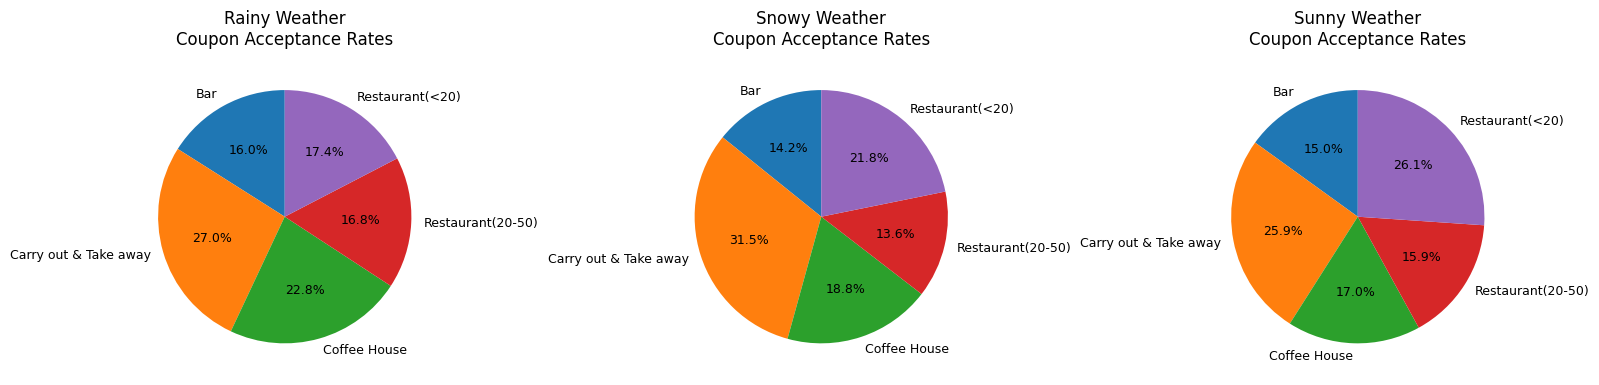

Carry-out coupons dominate acceptance across all weather conditions, representing 27-32% of
total acceptance rates and peaking in snowy weather (31.5%) when convenience is prioritized.
Cheap restaurants (<$20) show the strongest weather sensitivity, accounting for 26.1% of acceptance
in sunny weather but dropping to 17.4% in rainy conditions. Coffee house coupons maintain consistent
acceptance (17-23%) across all weather patterns, confirming coffee as a weather-independent need.
Bar coupons show the lowest acceptance rates (13-16%) regardless of weather, while expensive
restaurants (20-50) remain stable at 13-17%. The data reveals that convenience-focused coupons
(carry-out) thrive in adverse weather when drivers avoid sit-down experiences, while casual dining
coupons require pleasant weather to drive acceptance.


In [1551]:
acceptance_by_weather_coupon = data.groupby(['weather', 'coupon'])['Y'].mean().reset_index()

# Create 3 subplots for pie charts
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

weather_conditions = ['Rainy', 'Snowy', 'Sunny']
axes = [ax1, ax2, ax3]

for ax, weather in zip(axes, weather_conditions):
    # Filter data for this weather condition
    weather_data = acceptance_by_weather_coupon[acceptance_by_weather_coupon['weather'] == weather]

    # Create pie chart
    ax.pie(weather_data['Y'], labels=weather_data['coupon'], autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 9})
    ax.set_title(f'{weather} Weather\nCoupon Acceptance Rates', fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('images/coupon_acceptance_by_weather_pie.png')
plt.show()

print("Carry-out coupons dominate acceptance across all weather conditions, representing 27-32% of\n"
"total acceptance rates and peaking in snowy weather (31.5%) when convenience is prioritized.\n"
"Cheap restaurants (<$20) show the strongest weather sensitivity, accounting for 26.1% of acceptance\n"
"in sunny weather but dropping to 17.4% in rainy conditions. Coffee house coupons maintain consistent\n"
"acceptance (17-23%) across all weather patterns, confirming coffee as a weather-independent need.\n"
"Bar coupons show the lowest acceptance rates (13-16%) regardless of weather, while expensive\n"
"restaurants (20-50) remain stable at 13-17%. The data reveals that convenience-focused coupons\n"
"(carry-out) thrive in adverse weather when drivers avoid sit-down experiences, while casual dining\n"
"coupons require pleasant weather to drive acceptance.")

# Correlation between passenger and coupon type

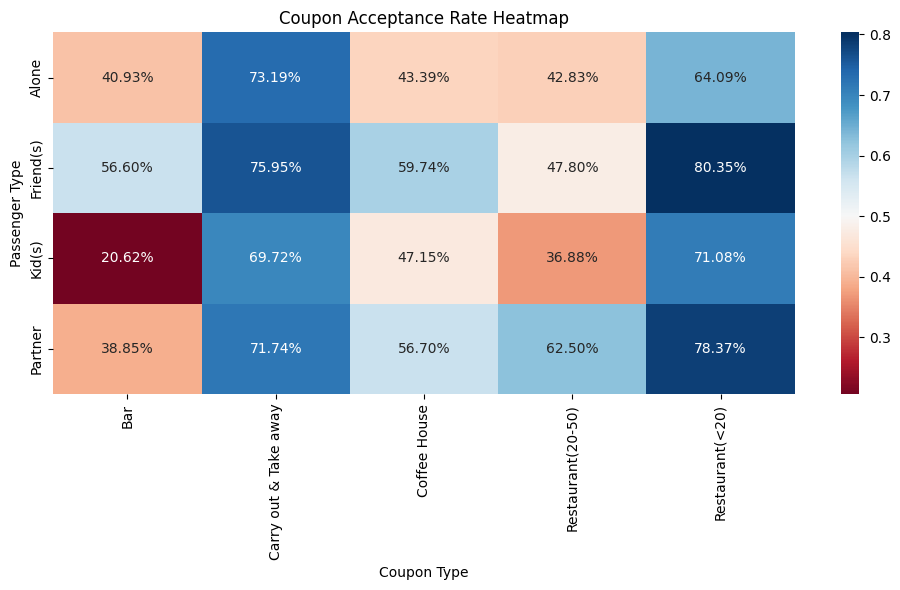

Carry-out coupons show the highest acceptance rates across all passenger types (70-76%),
with friends as passengers yielding the best results (80.35% for cheap restaurants, 75.95%
for carry-out). Bar coupons perform poorly when traveling with kids (20.62%) but improve
significantly when alone or with friends (56-73%). Expensive restaurants (20-50) show moderate
acceptance with partners (62.50%) but struggle with solo drivers and kids (37-48%).

The data reveals that social context strongly influences coupon acceptance, with friend passengers
driving the highest rates across all coupon types, while kid passengers suppress acceptance for
adult-oriented venues like bars and expensive restaurants.


In [1552]:
# Heatmap
pivot_table = data.pivot_table(values='Y', index='passenger', columns='coupon', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.2%', cmap='RdBu', center=0.5)
plt.title('Coupon Acceptance Rate Heatmap')
plt.ylabel('Passenger Type')
plt.xlabel('Coupon Type')
plt.tight_layout()
plt.savefig('images/coupon_acceptance_heatmap.png')
plt.show()

print("Carry-out coupons show the highest acceptance rates across all passenger types (70-76%),\n"
      "with friends as passengers yielding the best results (80.35% for cheap restaurants, 75.95%\n"
      "for carry-out). Bar coupons perform poorly when traveling with kids (20.62%) but improve\n"
      "significantly when alone or with friends (56-73%). Expensive restaurants (20-50) show moderate\n"
      "acceptance with partners (62.50%) but struggle with solo drivers and kids (37-48%).\n\n"
      "The data reveals that social context strongly influences coupon acceptance, with friend passengers\n"
      "driving the highest rates across all coupon types, while kid passengers suppress acceptance for\n"
      "adult-oriented venues like bars and expensive restaurants.")


# Correlation between passenger and coupon issue time

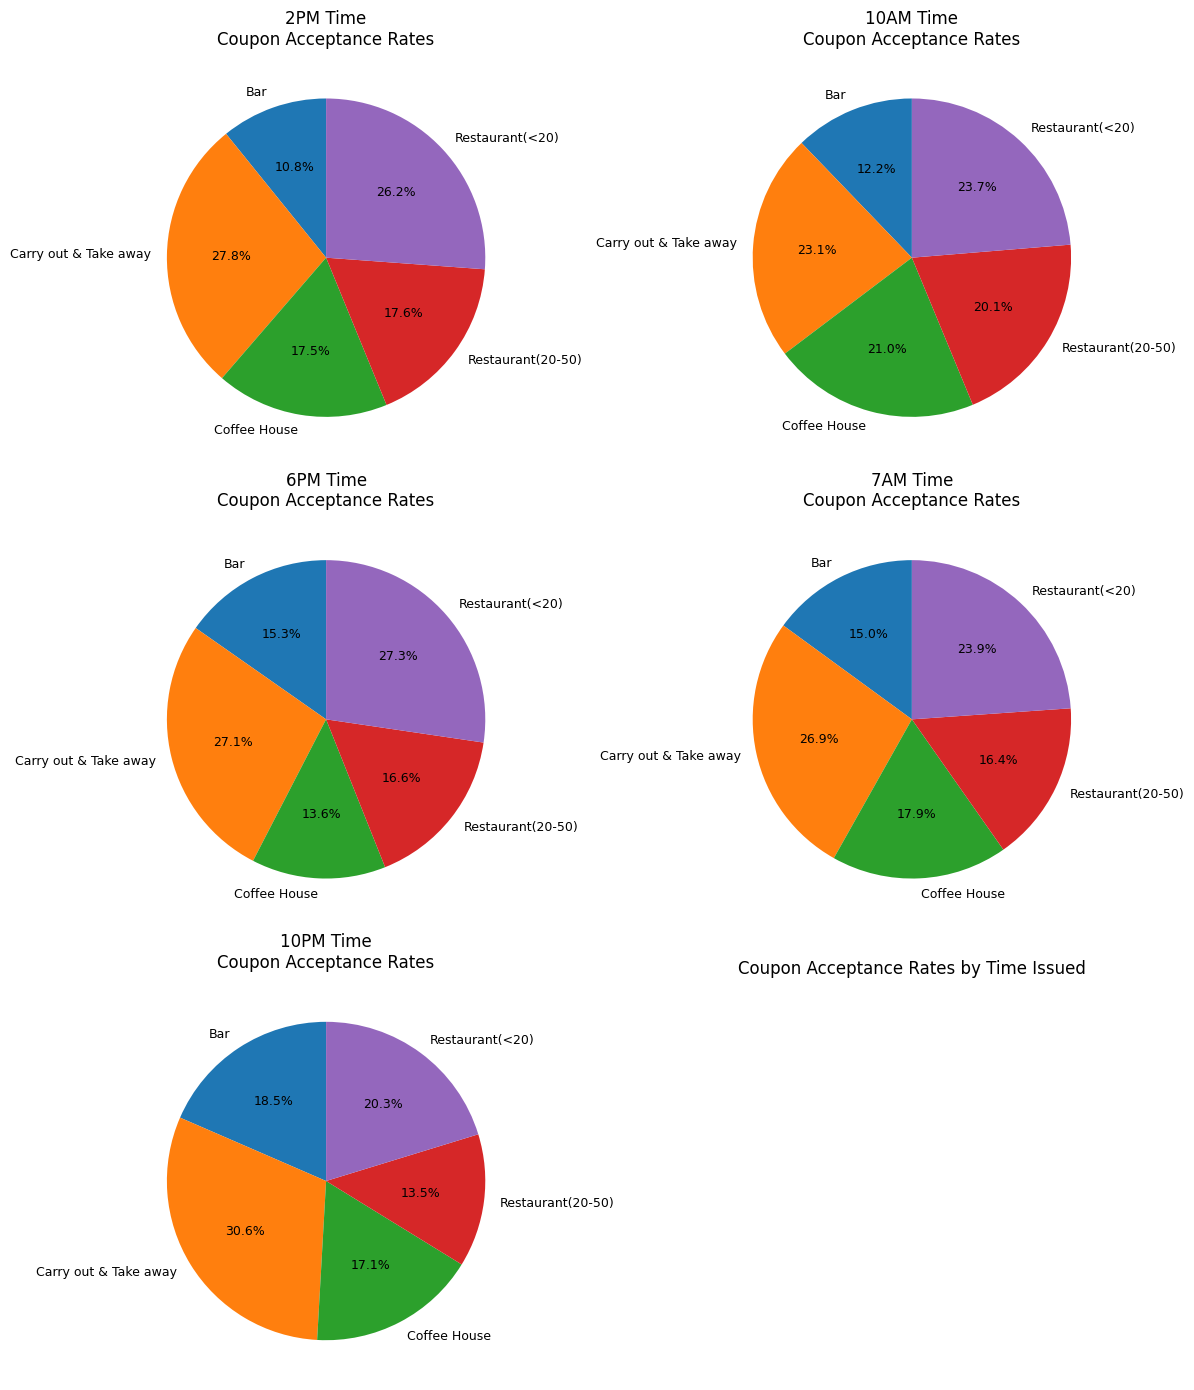

Carry-out coupons maintain consistently high acceptance rates regardless of the time of day,
demonstrating their appeal as a convenient dining option at any hour. In contrast, bar coupons
show strong time-dependent patterns, with peak acceptance at 10 PM when social and nightlife
activities are most common, and lowest acceptance at 2 PM during typical work hours when bar
visits are less socially appropriate. This suggests that coupon acceptance for experience-based
venues like bars is heavily influenced by the social context and appropriateness of the activity
at different times of day, while convenience-focused options like carry-out remain consistently
attractive across all time periods.


In [1553]:
# Coupon acceptance by time condition (pie charts)
acceptance_by_time_coupon = data.groupby(['time', 'coupon'])['Y'].mean().reset_index()

times = data['time'].unique()
no_of_times = len(times)

# Create subplots in 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()  # Flatten to make indexing easier

time_conditions = list(times)

for idx, time_item in enumerate(time_conditions):
    # Filter data for this time condition
    time_data = acceptance_by_time_coupon[acceptance_by_time_coupon['time'] == time_item]

    # Create pie chart
    axes[idx].pie(time_data['Y'], labels=time_data['coupon'], autopct='%1.1f%%',
                  startangle=90, textprops={'fontsize': 9})
    axes[idx].set_title(f'{time_item} Time\nCoupon Acceptance Rates', fontsize=12, pad=10)

# Hide any unused subplots if there are fewer than 6 time periods
for idx in range(no_of_times, 6):
    axes[idx].axis('off')

plt.tight_layout()
plt.title('Coupon Acceptance Rates by Time Issued')
plt.savefig('images/coupon_acceptance_by_time_pie.png')
plt.show()

print("Carry-out coupons maintain consistently high acceptance rates regardless of the time of day,\n"
      "demonstrating their appeal as a convenient dining option at any hour. In contrast, bar coupons\n"
      "show strong time-dependent patterns, with peak acceptance at 10 PM when social and nightlife\n"
      "activities are most common, and lowest acceptance at 2 PM during typical work hours when bar\n"
      "visits are less socially appropriate. This suggests that coupon acceptance for experience-based\n"
      "venues like bars is heavily influenced by the social context and appropriateness of the activity\n"
      "at different times of day, while convenience-focused options like carry-out remain consistently\n"
      "attractive across all time periods.")